Perform bootstrap resampling to measure how often player form features contribute to the simple market odds and Dixon-Coles model.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

predictions = pd.read_csv(Path(r"C:\Users\skous\Super-League-odds-research\artifacts\scotland_model_evaluation\predictions.csv"))
predictions["match_date"] = pd.to_datetime(predictions["match_date"])

In [3]:
def comparison_prep(predictions, baseline_model, enhanced_model):
    keys = ["match_id", "season", "match_date", "result_3way"]
    probability_columns = ["prob_H", "prob_D", "prob_A"]

    baseline = predictions.loc[predictions["model"] == baseline_model, keys + probability_columns].copy()
    enhanced = predictions.loc[predictions["model"] == enhanced_model, keys + probability_columns].copy()

    baseline = baseline.rename(columns={column: f"baseline_{column}" for column in probability_columns})
    enhanced = enhanced.rename(columns={column: f"enhanced_{column}" for column in probability_columns})

    data = baseline.merge(enhanced, on=keys, how="inner", validate="one_to_one")

    result_index = data["result_3way"].map({"H": 0, "D": 1, "A": 2}).to_numpy()
    row_index = np.arange(len(data))

    baseline_probabilities = data[["baseline_prob_H", "baseline_prob_D", "baseline_prob_A"]].to_numpy()
    enhanced_probabilities = data[["enhanced_prob_H", "enhanced_prob_D", "enhanced_prob_A"]].to_numpy()

    actual_baseline_probability = baseline_probabilities[row_index, result_index]
    actual_enhanced_probability = enhanced_probabilities[row_index, result_index]

    data["baseline_loss"] = -np.log(np.clip(actual_baseline_probability, np.finfo(float).eps, 1))
    data["enhanced_loss"] = -np.log(np.clip(actual_enhanced_probability, np.finfo(float).eps, 1))
    data["improvement"] = data["baseline_loss"] - data["enhanced_loss"]
    data["match_week"] = data["match_date"].dt.to_period("W-MON").astype(str)

    if len(data) != len(baseline) or len(data) != len(enhanced):
        raise ValueError("The two models do not contain exactly the same matches.")

    return data

In [4]:
def resample_match_weeks(data, reps=10_000, seed=42):
    weekly = data.groupby(["season", "match_week"], as_index=False).agg(matches=("match_id", "size"), baseline_loss=("baseline_loss", "sum"), improvement=("improvement", "sum"))
    season_blocks = [group[["matches", "baseline_loss", "improvement"]].to_numpy() for _, group in weekly.groupby("season", sort=False)]

    rng = np.random.default_rng(seed)
    results = np.empty((reps, 2))

    for repetition in range(reps):
        total_matches = 0
        total_baseline_loss = 0
        total_improvement = 0

        for blocks in season_blocks:
            selected = blocks[rng.integers(0, len(blocks), size=len(blocks))]
            total_matches += selected[:, 0].sum()
            total_baseline_loss += selected[:, 1].sum()
            total_improvement += selected[:, 2].sum()

        results[repetition, 0] = total_improvement / total_matches
        results[repetition, 1] = 100 * total_improvement / total_baseline_loss

    return pd.DataFrame(results, columns=["average_improvement", "relative_improvement_pct"])

In [5]:
COMPARISONS = {"Market + player form": ("closing_market", "market_plus_player_form"), "Dixon–Coles + player form": ("dixon_coles", "dixon_coles_player_form")}

summary_rows = []
resampled_results = {}

for comparison, (baseline_model, enhanced_model) in COMPARISONS.items():
    comparison_data = comparison_prep(predictions, baseline_model, enhanced_model)
    samples = resample_match_weeks(comparison_data)
    resampled_results[comparison] = samples

    observed_improvement = 100 * comparison_data["improvement"].sum() / comparison_data["baseline_loss"].sum()
    lower_limit, upper_limit = samples["relative_improvement_pct"].quantile([0.025, 0.975])
    improvement_frequency = 100 * (samples["relative_improvement_pct"] > 0).mean()

    summary_rows.append({"comparison": comparison, "matches": len(comparison_data), "observed_improvement_pct": observed_improvement, "lower_95_pct": lower_limit, "upper_95_pct": upper_limit, "repetitions_favouring_player_pct": improvement_frequency})

In [6]:
summary = pd.DataFrame(summary_rows)
summary.style.format({"observed_improvement_pct": "{:+.2f}%", "lower_95_pct": "{:+.2f}%", "upper_95_pct": "{:+.2f}%", "repetitions_favouring_player_pct": "{:.1f}%"})

,comparison,matches,observed_improvement_pct,lower_95_pct,upper_95_pct,repetitions_favouring_player_pct
0,Market + player form,665,-2.19%,-3.75%,-0.53%,0.5%
1,Dixon–Coles + player form,665,-0.53%,-1.22%,+0.16%,6.6%


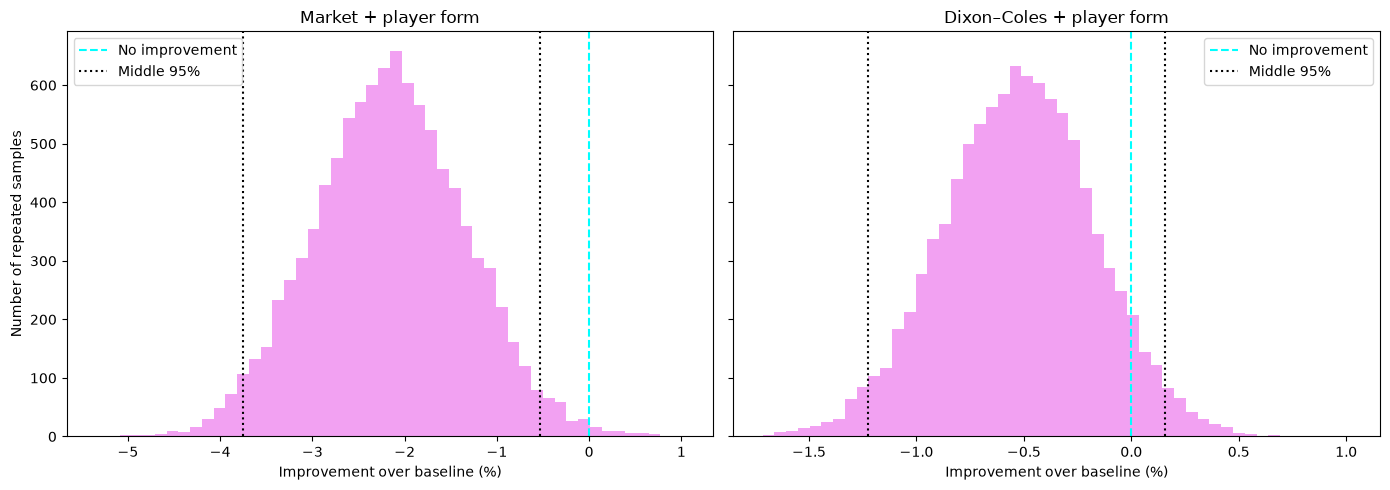

In [9]:
fig, axes = plt.subplots(1, len(resampled_results), figsize=(14, 5), sharey=True)
plt.style.use("default")
axes = np.atleast_1d(axes)

for axis, (comparison, samples) in zip(axes, resampled_results.items()):
    values = samples["relative_improvement_pct"]
    lower_limit, upper_limit = values.quantile([0.025, 0.975])

    axis.hist(values, bins=50, color="violet", alpha=0.75)
    axis.axvline(0, color="cyan", linestyle="--", label="No improvement")
    axis.axvline(lower_limit, color="black", linestyle=":", label="Middle 95%")
    axis.axvline(upper_limit, color="black", linestyle=":")
    axis.set_title(comparison)
    axis.set_xlabel("Improvement over baseline (%)")
    axis.legend()

axes[0].set_ylabel("Number of repeated samples")
plt.tight_layout()

output_path = Path("../visuals/out") / "feature_contribution.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight")

plt.show()

The resampled outcomes are concentrated below zero for both comparisons. Player form generally reduces predictive performance.

For the market model, the entire middle 95% lies between −3.75% and −0.53%, with only 0.5% of repetitions showing improvement. This is strong evidence that adding player form made the market model worse.

For Dixon–Coles, the distribution is closer to zero ~ the middle 95% ranges from −1.22% to +0.16%. *A small benefit remains possible*, but only 6.6% of repetitions favor player form.

## Currently player form provides no improvement in 93% matches (significant :/ ), giving slightly worse odds for most match outcomes